In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import tensorflow as tf
import os
import random

In [10]:
def transform(image):
    gray_img = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    moments = cv.moments(gray_img)
    image = cv.HuMoments(moments).flatten()
    return image

In [13]:
root = './train'
buckets = {}
images = []
labels = []
i = 0
for img_name in os.listdir(root):
    if i == 100: break
    class_img = img_name.split('_')[0]
    if class_img == 'nv': continue
    img = cv.imread(os.path.join(root,img_name))
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img = cv.resize(img, (196, 196))
    hu = transform(img)
    if class_img in buckets: buckets[class_img]+=1
    else: buckets[class_img] = 0
    img = np.array(img).flatten()
    np.concatenate(img,hu)
    images.append(img)
    labels.append(class_img)

TypeError: only integer scalar arrays can be converted to a scalar index

In [12]:
i = random.randint(0, len(images))
img = np.array(images[i])
print(img.shape)

(115248,)


TypeError: Invalid shape (7,) for image data

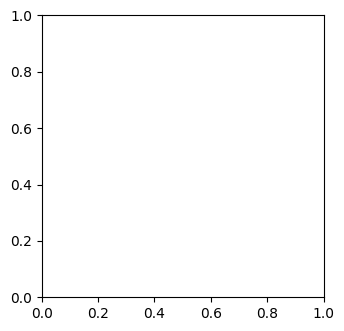

In [4]:
i = random.randint(0,len(images))
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(images[i])
plt.title(labels[i])
i = random.randint(0,len(images))
plt.subplot(1,2,2)
plt.imshow(images[i])
plt.title(labels[i])
plt.tight_layout()
plt.show()

In [ ]:
print(buckets)

{'bkl': 1098, 'mel': 1112, 'df': 114, 'bcc': 513, 'akiec': 326, 'vasc': 141}


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels = le.fit_transform(labels)
images = np.array(images)/255.0
labels = np.array(labels)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, shuffle=True, random_state=42)

Text(0.5, 1.0, '4, test')

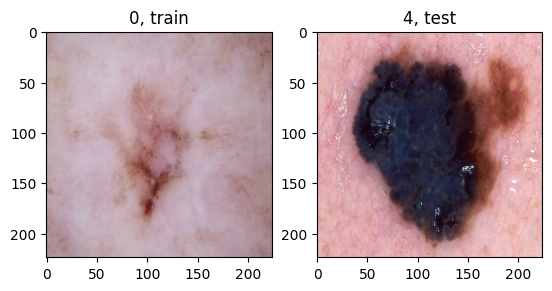

In [ ]:
plt.subplot(1,2,1)
i = random.randint(0,len(X_train))
plt.imshow(X_train[i])
plt.title(f'{y_train[i]}, train')
i = random.randint(0,len(X_test))
plt.subplot(1,2,2)
plt.imshow(X_test[i])
plt.title(f'{y_test[i]}, test')

In [ ]:
# bucks = {}
# train_dir = './train_dir'
# test_dir = './test_dir'
# for i in range(len(y_train)):
#     dx = le.inverse_transform([y_train[i]])[0]
#     if dx in bucks: bucks[dx]+=1
#     else: bucks[dx] = 0
#     img = cv.cvtColor(X_train[i], cv.COLOR_RGB2BGR)
#     cv.imwrite(os.path.join(train_dir, f'{dx}_{bucks[dx]}.jpg'), img)

# print('train: ',bucks)
# bucks = {}
# for i in range(len(y_test)):
#     dx = le.inverse_transform([y_test[i]])[0]
#     if dx in bucks: bucks[dx]+=1
#     else: bucks[dx] = 0
#     img = cv.cvtColor(X_test[i], cv.COLOR_RGB2BGR)
#     cv.imwrite(os.path.join(test_dir, f'{dx}_{bucks[dx]}.jpg'), img)
# print('test: ',bucks)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(196, 196, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dense(6, activation='sigmoid')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# callbacks = [ tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5), 
#             tf.keras.callbacks.ModelCheckpoint(filepath='model.{epoch:02d}-{val_loss:.2f}.h5') ]

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
83/83 [==============================] - 197s 2s/step - loss: 3.9526 - accuracy: 0.4275 - val_loss: 4.5920 - val_accuracy: 0.1329
Epoch 2/20
83/83 [==============================] - 198s 2s/step - loss: 1.3867 - accuracy: 0.5329 - val_loss: 2.9863 - val_accuracy: 0.3218
Epoch 3/20
83/83 [==============================] - 172s 2s/step - loss: 1.1126 - accuracy: 0.5993 - val_loss: 4.0379 - val_accuracy: 0.1480
Epoch 4/20
83/83 [==============================] - 153s 2s/step - loss: 0.9744 - accuracy: 0.6416 - val_loss: 3.7166 - val_accuracy: 0.3474
Epoch 5/20
83/83 [==============================] - 148s 2s/step - loss: 0.7424 - accuracy: 0.7096 - val_loss: 2.1493 - val_accuracy: 0.3807
Epoch 6/20
83/83 [==============================] - 162s 2s/step - loss: 0.6504 - accuracy: 0.7526 - val_loss: 1.7254 - val_accuracy: 0.4063
Epoch 7/20
83/83 [==============================] - 172s 2s/step - loss: 0.5705 - accuracy: 0.7893 - val_loss: 1.5194 - val_accuracy: 0.5710
Epoch 8/20
83

In [ ]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print('Test Accuracy: %.3f' % acc)

Test Accuracy: 0.536


21/21 [==============================] - 10s 472ms/step


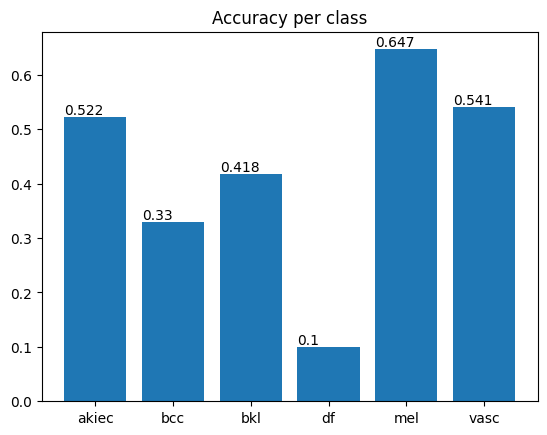

In [ ]:
y_pred = model.predict(X_test)
y_pred_label = np.argmax(y_pred, axis=1)
y_test_label = np.argmax(y_test, axis=1)
# make a bargraph of accuracy per class
from sklearn.metrics import accuracy_score
acc_per_class = []
for i in range(6):
    acc_per_class.append(accuracy_score(y_test_label[y_test_label==i], y_pred_label[y_test_label==i]))

bars  = plt.bar(le.classes_, acc_per_class)
plt.title('Accuracy per class')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x(), yval + .005, round(yval,3))
plt.show()
# plt.bar(le.classes_, acc_per_class)
# plt.title('Accuracy per class')
# plt.show()

Text(0, 0.5, 'Loss')

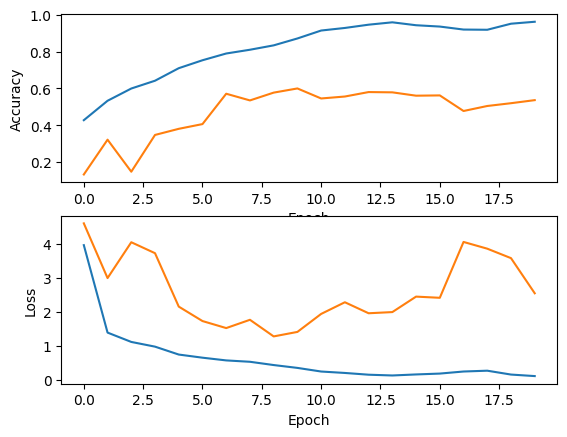

In [ ]:
model.save('model_black_hat.keras')
plt.subplot(2,1,1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(2,1,2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')